# Coverage Planners

This section presents the coverage planning algorithms employed in this study. While a comprehensive technical analysis of these algorithms is beyond the scope of this work, \
they are described with sufficient detail to enable understanding of their application within our framework. \
For in-depth technical details and formal derivations, the reader is referred to the original publications cited herein.

In order to demonstrate the different navigators, \
we use a map provided by the [mirte navigation](https://github.com/MartijnWisse/mirte_navigation) ros2 package. \
{numref}`original costmap` shows the costmap generated by Nav2

```{figure} figures/original_costmap.pgm.*
:label: original_costmap
:alt: Costmap used as an example in this section

In [11]:
import cv2

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
from matplotlib.widgets import Slider

from local_codebase.imports.navigator_types import SystematicNavigator
from local_codebase.imports.navigators import BousPath, SkeletonPath


def show_imgs(imgs, labels):
    n = len(imgs)
    fig, ax = plt.subplots(1, n, figsize=(6 * n, 6))

    if n == 1:
        ax = [ax]

    for i in range(n):
        img = cv2.normalize(imgs[i], None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
        ax[i].imshow(img, cmap="gray")
        ax[i].set_title(labels[i])
        ax[i].axis("off")
    plt.tight_layout()
    plt.show()
    
path = "local_codebase/maps/lc_costmap.pgm"
map_img = cv2.bitwise_not(cv2.imread(path, cv2.IMREAD_UNCHANGED))
# show_imgs([map_img], ["Initial Costmap"])

## Free space Polygon

Each defined navigator is a derived class of `SystematicNavigator`, a metaclass encompassing all navigators \
that plan coverage paths over the whole free space area. Standard for the derived classes is that they \
update their internal map and as a result plan a path over this map.

`update_map()` first takes the costmap and, given a threshold, sets the free space to [0, 0, 0] and occupied space [255, 255, 255]. \
It then uses `opencv.findContours()` to find the free space boundaries and saves these as contours.


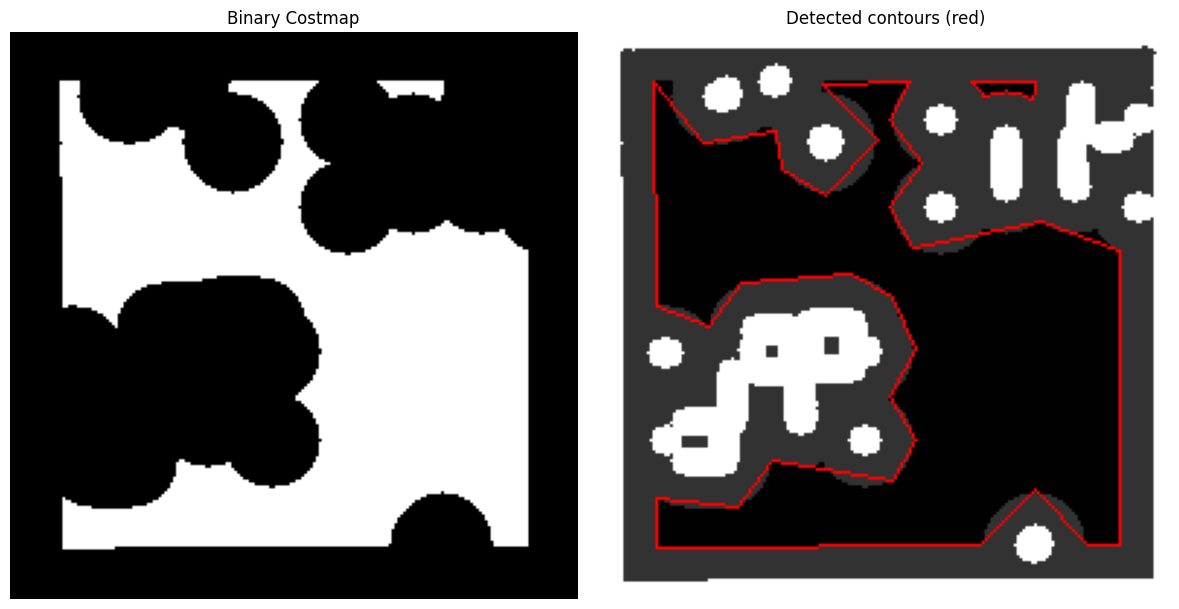

In [3]:
navigator = SystematicNavigator()

navigator.update_map(map_img)
contours = navigator.contours

color_img = cv2.cvtColor(map_img, cv2.COLOR_GRAY2RGB)
contour_img = cv2.drawContours(color_img, contours, -1, (255, 0, 0), 1)

show_imgs(
        [navigator.binary_costmap, contour_img], ["Binary Costmap", "Detected contours (red)"],
    )

## BousPath

The first navigator that will be covered is a Boustropedon based Coverage planner. \
This navigator plans in two steps:

- Decomposition
- Swath Generation


### Boustropedon Cellular Decomposition


Contours: 2
0: 32 points
1: 17 points
Performing Decomposition
map decomposed, publishing decomposition


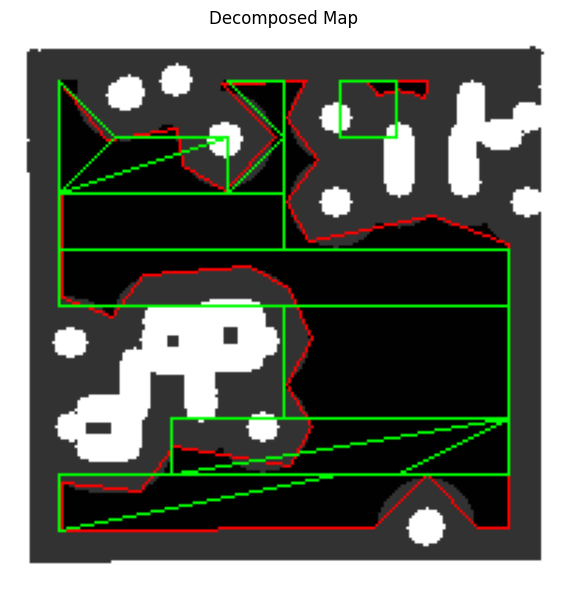

In [4]:
# Update internal map
navigator = BousPath()
navigator.update_map(map_img)

# Perform Boustropethan Celular Decomposition
navigator.bcd()
pixel_cells = [navigator.world_to_pixel(poly) for poly in navigator.raw_cells]

decomp_img = cv2.drawContours(color_img, pixel_cells, -1, (0, 255, 0), 1)
show_imgs([decomp_img], ["Decomposed Map"])

### Boustrophedon Path Generation


Number of cells: 16
generating full trajectory


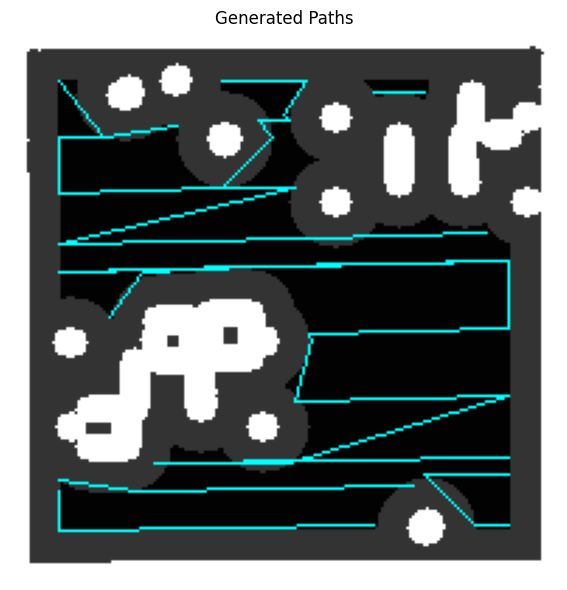

In [5]:
navigator.bous_path()
paths = navigator.paths

swath_img = cv2.cvtColor(map_img, cv2.COLOR_GRAY2RGB)

for path in paths:
    pts = np.array(navigator.world_to_pixel_path(path), dtype=np.int32)

    swath_img = cv2.polylines(
        swath_img, [pts], isClosed=False, color=(0, 255, 255), thickness=1
    )
show_imgs([swath_img], ["Generated Paths"])

## SkeletonPath

The `SkeletonPath` planner is a topology-based coverage planner that generates navigation paths using the morphological skeleton of the environment.

Unlike the `BousPath` planner, which decomposes the free space into sweepable cells, the skeleton planner reduces the free space to a graph-like centerline representation. This representation preserves the connectivity of the environment while simplifying path planning.

The implementation is inspired by recent work in morphology-based exploration and autonomous navigation.

---

### Planner Initialization

The planner can be initialized similarly to the other navigators:


In [6]:
navigator = SkeletonPath()

navigator.update_map(map_img)

### Reading and Skeletonizing the Map

The skeleton planner generates a morphological skeleton using the `read()` method

Internally, the planner:

1. fills the free-space contours,
2. skeletonizes the free-space region,
3. extracts skeleton pixels,
4. converts them into Cartesian waypoints.

The generated waypoints are stored in `waypoints`


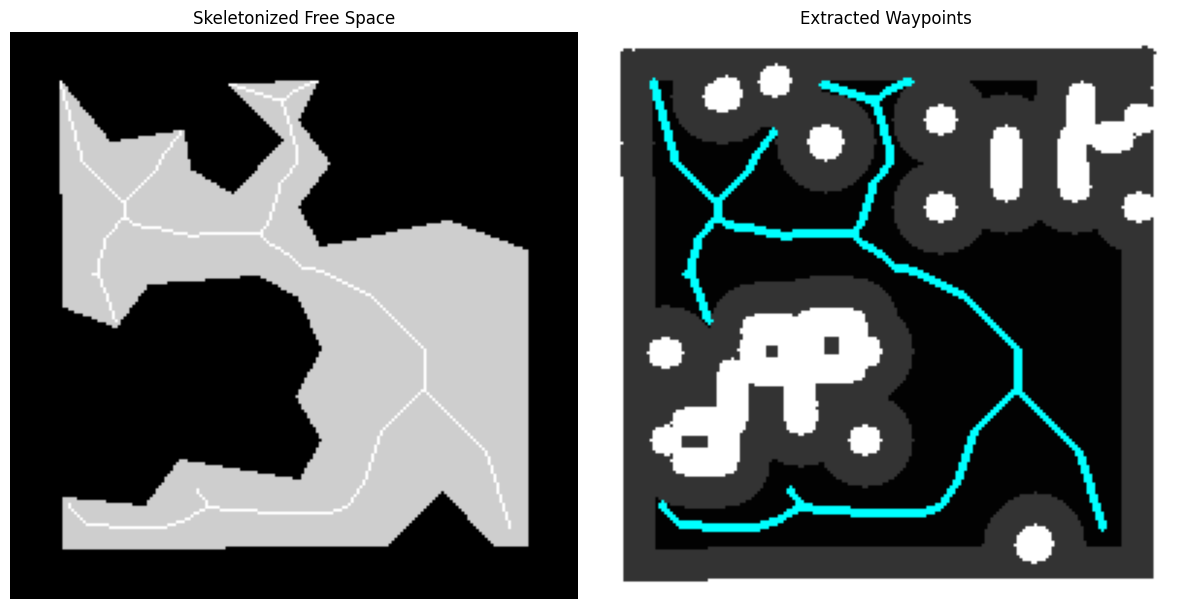

In [7]:
navigator.read()

skeleton_img = cv2.addWeighted(
    navigator.contour_img,
    0.8,
    navigator.skeleton_map,
    0.2,
    0,
)

# Convert grayscale map to RGB so we can draw colored points
waypoint_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

# Convert waypoint coordinates (meters) back to image pixels
pts = []

for point in navigator.waypoints:
    x_world, y_world = point

    # Convert world -> image coordinates
    px = int((x_world / navigator.map_resolution) + navigator.origin[1])
    py = int((y_world / navigator.map_resolution) + navigator.origin[0])

    pts.append((px, py))

# Draw every waypoint
for pt in pts:
    cv2.circle(waypoint_img, pt, radius=1, color=(0, 255, 255), thickness=-1)

show_imgs(
    [skeleton_img, waypoint_img], ["Skeletonized Free Space", "Extracted Waypoints"]
)

### Path Planning

After the waypoints have been generated, they are then sampled and ordered. \
The algorithm does this by first constructing a graph representation of the skeleton tree. \
The waypoints then become graph nodes. Edges are generated between the nodes with a certain distance threshold \
finding leaf nodes, meaning nodes with only one connection (green), \

To efficiently identify neighboring points, a k-d tree is used for spatial indexing. \
Starting from the closest waypoint to the robot, the algorithm recursively explores nearby nodes and connects them within the graph, \

Leaf nodes are then identified in the tree, (nodes with one connection).


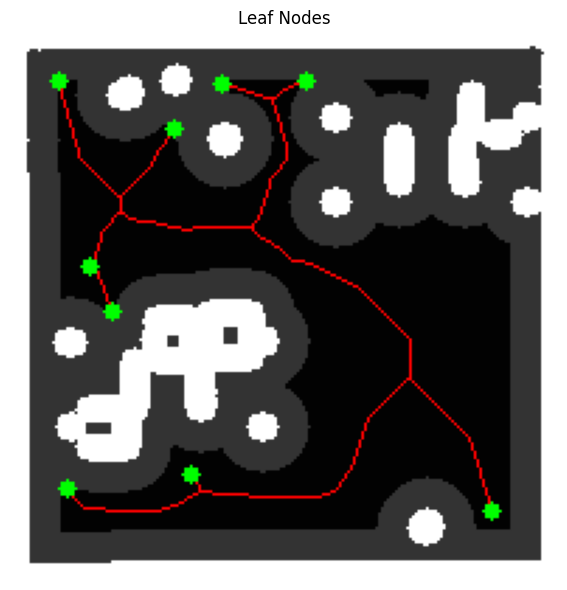

In [8]:
# Generate waypoint graph
navigator.set_waypoints(distance=5.0)

# Create visualization image
graph_img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

# Draw graph edges
for edge in navigator.graph.edges:

    n1, n2 = edge

    p1 = navigator.graph.nodes[n1]["pos"]
    p2 = navigator.graph.nodes[n2]["pos"]

    # Convert world -> image coordinates
    x1 = int((p1[0] / navigator.map_resolution) + navigator.origin[1])
    y1 = int((p1[1] / navigator.map_resolution) + navigator.origin[0])

    x2 = int((p2[0] / navigator.map_resolution) + navigator.origin[1])
    y2 = int((p2[1] / navigator.map_resolution) + navigator.origin[0])

    cv2.line(graph_img, (x1, y1), (x2, y2), (255, 0, 0), 1)

# Highlight leaf nodes
leaf_nodes = navigator.find_leaf_nodes()

for node in leaf_nodes:

    point = navigator.graph.nodes[node]["pos"]

    px = int((point[0] / navigator.map_resolution) + navigator.origin[1])
    py = int((point[1] / navigator.map_resolution) + navigator.origin[0])

    leaf_img = cv2.circle(
        graph_img, (px, py), radius=3, color=(0, 255, 0), thickness=-1
    )

show_imgs([graph_img], ["Leaf Nodes"])

### Path Ordering

First the closest leaf node to the robot is found, this is the starting position. \
The planner traces a path along the tree and selects the shortest one to the next leaf node. \
It then appends these points to the path and sets this new leaf node as the current one and marks it as visited. \
The algorithm repeats this process untill all leaf nodes have been explored successfully.


In [ ]:
# --------------------------------------------------
# Generate planner path
# --------------------------------------------------

navigator.start = [0, 0]
navigator.plan_path()

path_points = navigator.path

path_pixels = np.array([
    (
        int((x / navigator.map_resolution) + navigator.origin[1]),
        int((y / navigator.map_resolution) + navigator.origin[0])
    )
    for x, y in path_points
])

if len(path_pixels) == 0:
    raise ValueError("Planner produced an empty path.")

# --------------------------------------------------
# Slider
# --------------------------------------------------

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(path_pixels) - 1,
    step=1,
    description="Waypoint",
    continuous_update=True,
    layout=widgets.Layout(width="800px")
)

# --------------------------------------------------
# Output area (IMPORTANT)
# --------------------------------------------------

out = widgets.Output()

# --------------------------------------------------
# Update function (FULL redraw each step)
# --------------------------------------------------

def update_robot(change):
    idx = change["new"]

    # rebuild image every time (this is the trick)
    img = cv2.cvtColor(map_img.copy(), cv2.COLOR_GRAY2RGB)

    cv2.polylines(
        img,
        [path_pixels.astype(np.int32)],
        False,
        (0, 255, 255),
        1
    )

    x, y = path_pixels[idx]
    cv2.circle(img, (x, y), 5, (0, 255, 0), -1)

    with out:
        clear_output(wait=True)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.title("Skeleton Path (interactive)")
        plt.axis("off")
        plt.show()

slider.observe(update_robot, names="value")

# --------------------------------------------------
# Display
# --------------------------------------------------

display(slider)
display(out)

# initial draw
update_robot({"new": 0})

found 9 leaf nodes


IntSlider(value=0, description='Waypoint', layout=Layout(width='800px'), max=696)

Output()